In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from tools import *
from fit_funcs import *
from entropy import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe
import utils.tools as tools

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# plt.rcParams["mathtext.fontset"] = "cm"
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

linestyle_ls = ['-','--',':', '-.']
linestyle = itertools.cycle(linestyle_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   
from scipy import stats

# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import splrep, splev
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import interp1d
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import fsolve

from mpl_toolkits.axes_grid1 import make_axes_locatable

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

base_dir = "../results/"

print(base_dir[2:])
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}


/Users/rafal.swietek/Projects/CODES/QHamSolver/QuadQSun/Jupter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
/results/


## TESTS

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15]
1000 0.5930024492277
1000 0.4107234794646736
1000 0.42910665799830405
1000 0.4142943532211719
1000 0.4051883754760371
1000 0.3813439423684578
1000 0.448007709602594
1000 0.3987458873199532
1000 0.4013859882957698
1000 0.40522884859473535
1000 0.4072703444920205
1000 0.43024291543385074
1000 0.3776566951818275
1000 0.39788850588938746
1000 0.3731627666064062
1000 0.05 0.418216594611526
1000 0.5734236979579055
1000 0.41170862168133565
1000 0.45200041257921464
1000 0.44354247811152475
1000 0.4066858051601077
1000 0.45253484697196344
1000 0.4088228582760808
1000 0.4118379627577252
1000 0.46167696164281957
1000 0.4408321229770418
1000 0.421846831701691
1000 0.4183306064096216
1000 0.4043948290069936
1000 0.41953364273037097
1000 0.3935677050341832
1000 0.1 0.4347159588665719
1000 0.5419440590832817
1000 0.43235111985246066
1000 0.4489458386079865
1000 0.4316724097292177
1000 

ZeroDivisionError: division by zero

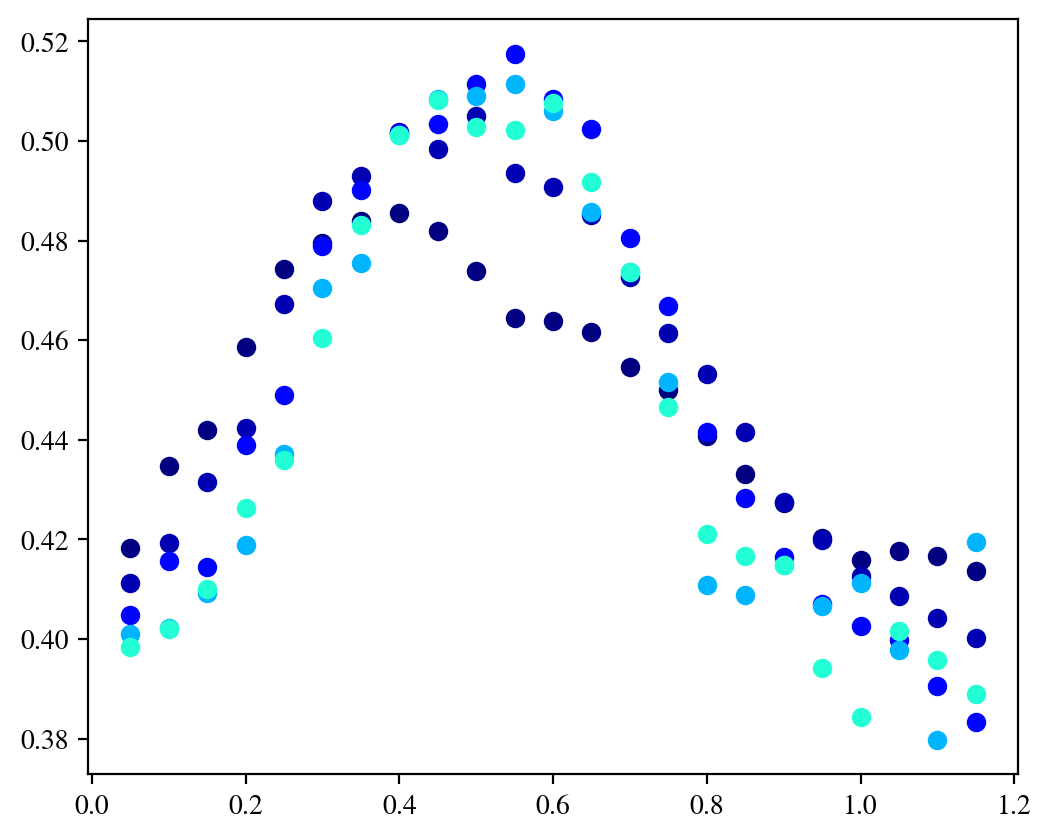

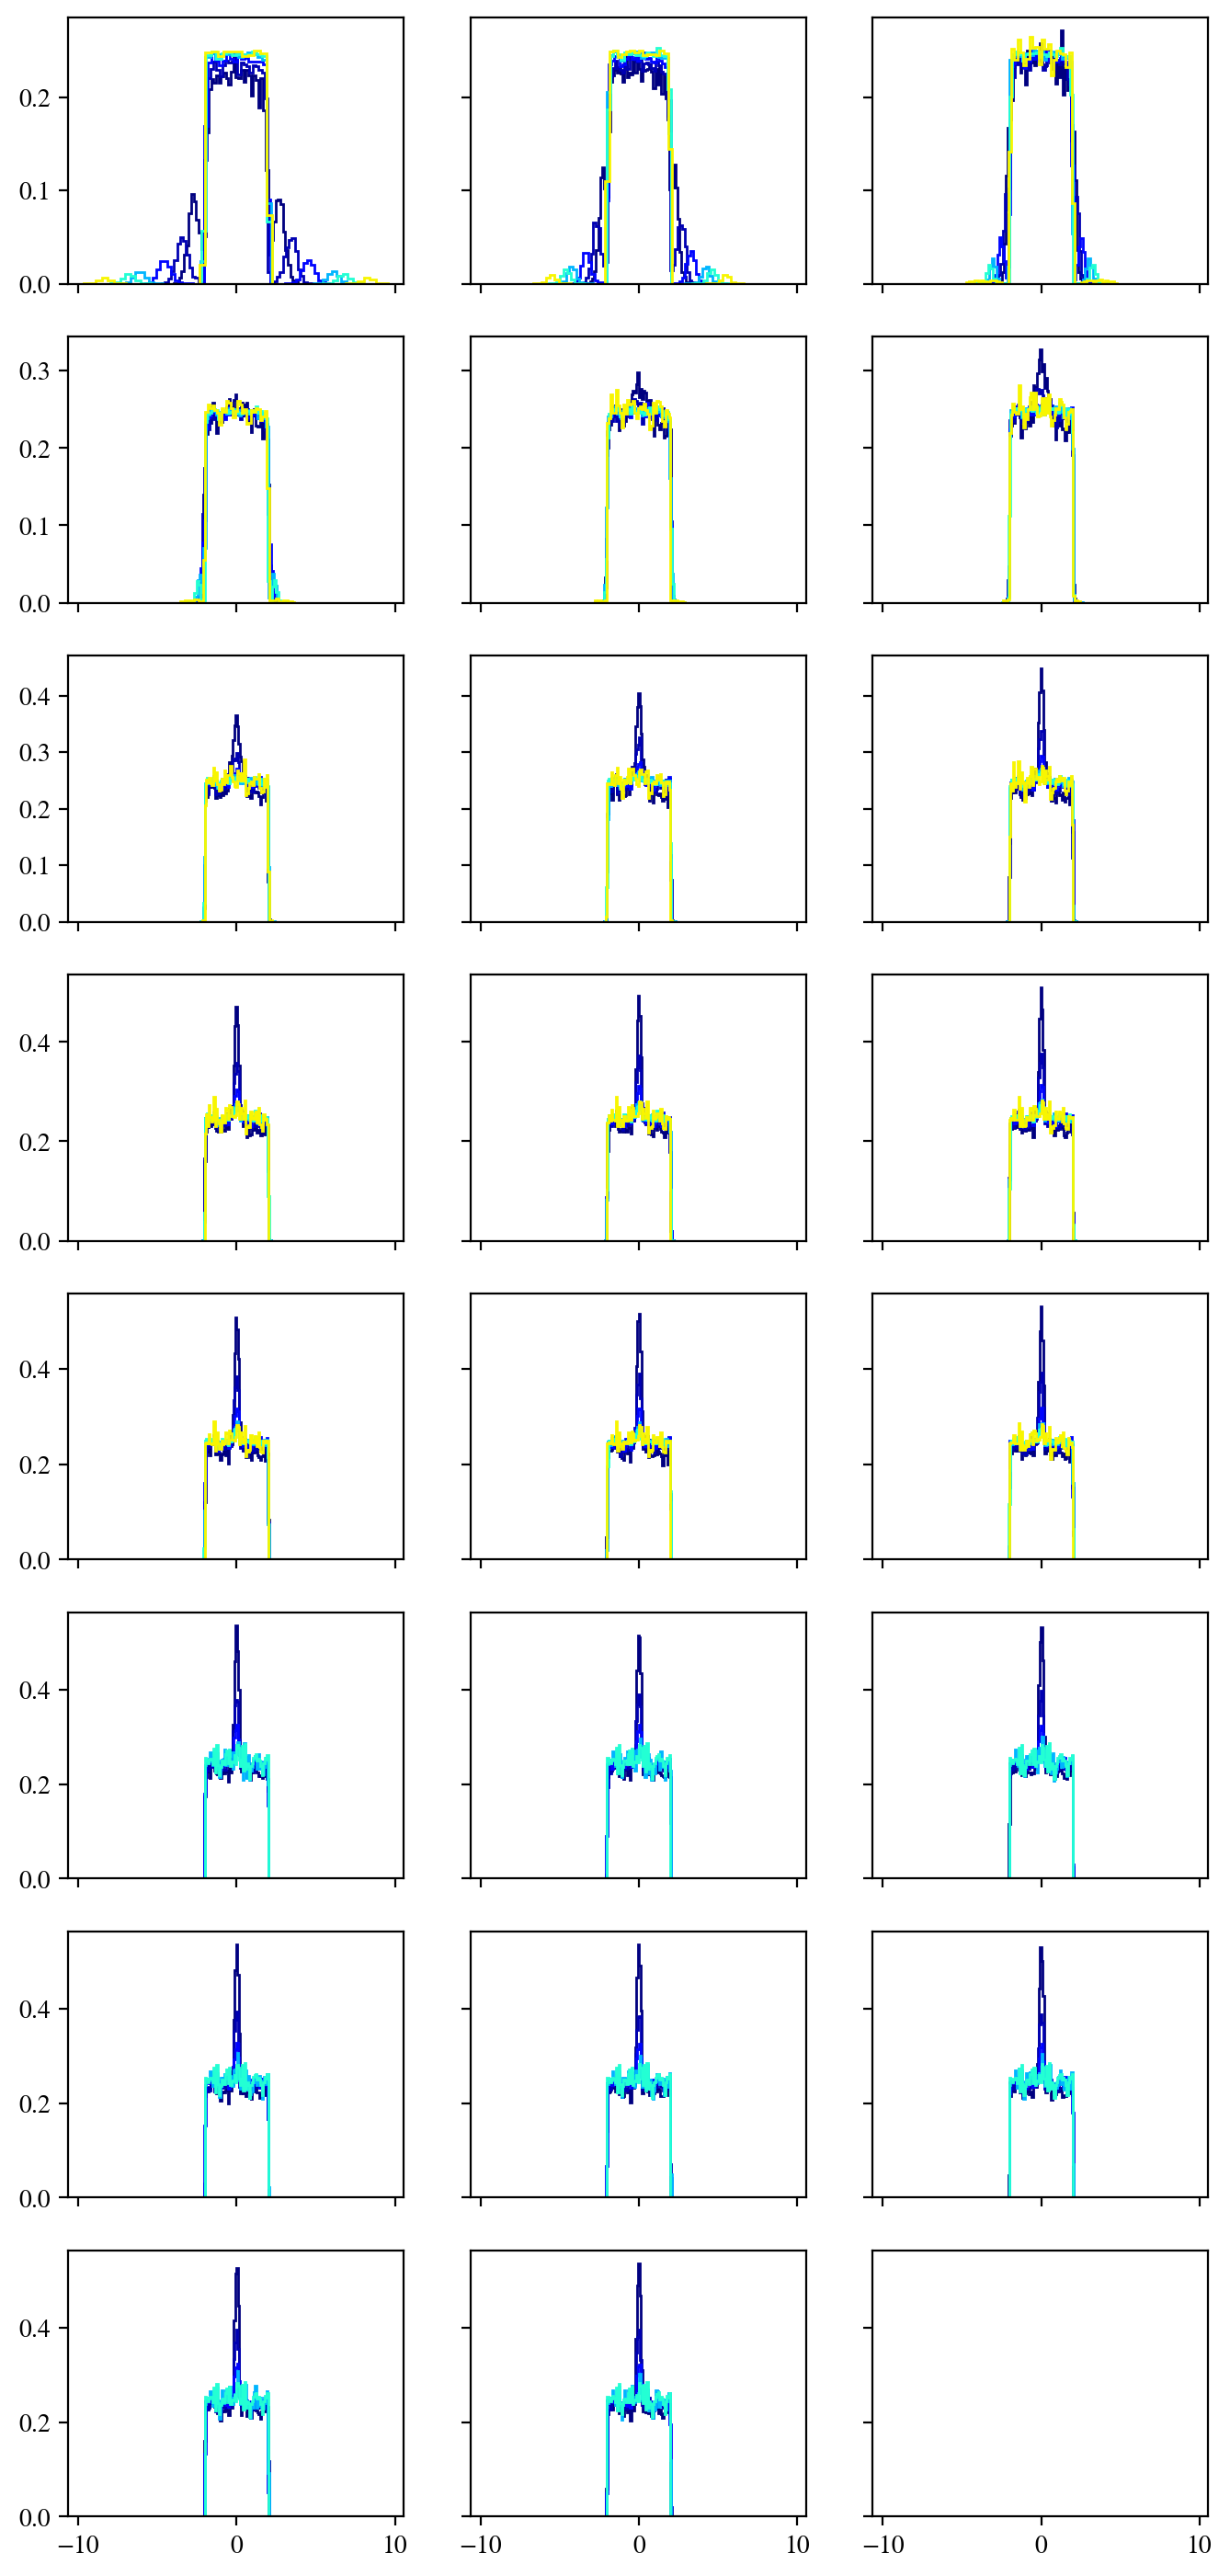

In [90]:
markers = itertools.cycle(markers_ls)

L_total=2600

J=1
alfa=1.0
h=0.0
w=2.
zeta=0.2

N=100
gamma=1
ini_ave=0
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745
window=4
projected = 0

alfa_vals = np.arange(0.05, 1.2, 0.05)
print(alfa_vals)

# alfa_vals = [1, 6, 16, 26, 36, 46]

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,5), dpi = 200)
figDOS, axDOS = plt.subplots( nrows=8, ncols=3, figsize=(8,18), dpi = 200, sharey = 'row', sharex = True)
axDOS = axDOS.flatten()

sizes = np.array( [1000, 2000, 4000, 8000, 10000, 16000, 20000, 24000] )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

for L in sizes:
    col = s_m.to_rgba(L)
    
    gap_ratio = []
    for iia, alfa in enumerate( alfa_vals ):
        r = 0
        counter = 0
        energies = []
        for real in range(15):
            name = base_dir + 'DIAGONALIZATION/realisation=%d/'%real + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
            if exists(name):
                with h5py.File(name, "r") as file:
                    E = np.array(file.get('eigenvalues'))[0]
                    energies.append(E)
                    _, indices, counts = np.unique(np.round(E, 14), return_index=True, return_counts=True)
                    if (indices[counts > 1]).size > 0:
                        print(indices[counts > 1])
                    
                    dim = E.size
                    gaps = np.diff(E)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    print(L, np.mean(ratio_tmp[dim//2 - 200 : dim//2 + 200]))
                    # r += np.mean(ratio_tmp[dim//4 : dim//4*3])
                    r += np.mean( ratio_tmp[dim//2 - 200 : dim//2 + 200] )
                    counter += 1
            else:
                print(name)
        gap_ratio.append( r / counter)
        print(L, alfa, r / counter)
        hist, bins = np.histogram( np.array(energies).flatten(), bins = 50, normed=True)
        axDOS[iia].stairs(hist, bins, color = col)
    axis.scatter(alfa_vals, gap_ratio, color = col)   
    
ylab = r"$\langle r\rangle$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='linear')

for iia, alfa in enumerate( alfa_vals ):
    fig_help.set_plot_elements(axDOS[iia], ylabel=r"$\rho(E)$" if iia%3 == 0 else "", xlabel=r"$E$" if iia>5 else "", font_size=16, set_legend=False, xscale='linear', yscale='linear')
    
fig.subplots_adjust(top=0.92)
cbar_ax = fig.add_axes([0.15, 0.95, 0.7, 0.04])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$\alpha$", fontsize=16)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')


fig.subplots_adjust(wspace = 0.23, hspace=0.13)
figDOS.subplots_adjust(wspace = 0.02, hspace=0.02)

## GAP RATIO

### MOBILITY EDGE

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


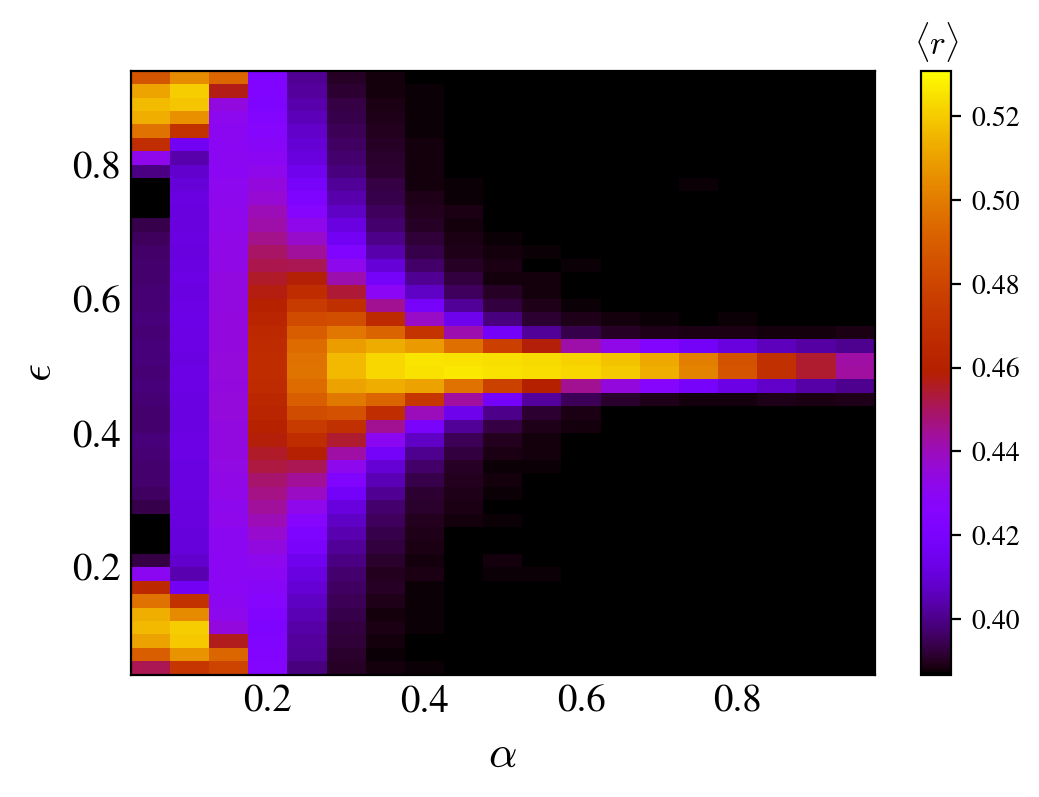

In [24]:

markers = itertools.cycle(markers_ls)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,4), dpi = 200)

J=1

alfa=0.6
h=0
w=2
zeta=0.2

N=500
gamma=1
ini_ave=0

L = 10000

alfa_vals = np.arange(0.05, 0.995, 0.05)
print(alfa_vals)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []
for ii, alfa in enumerate(alfa_vals):
    name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('energy_density'))
            # E = E[1:-1]
            gap_ratio = np.array(file.get('gap_ratio_density'))#[1:-1]
            # gap_ratio = (gap_ratio - 0.3867) / (0.5307 - 0.3867)
            gap_ratio_density.append(gap_ratio)
            energy_density = E
    else:
        print(name)

energy_density = np.array(energy_density)
gap_ratio_density = np.array(gap_ratio_density)

interaction = np.array([alfa_vals for _ in energy_density])

#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('gnuplot', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(alfa_vals, energy_density)

p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest', cmap=mymap, vmin=0.3867, vmax=0.5309)
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\alpha$", font_size=14, set_legend=False)
# axis.set_title(r"$L=%d, N=%d, g_0=%.2f$"%(L, N, J), fontsize=16)
clb = fig.colorbar(p)
clb.ax.set_title(r"$\langle r\rangle$")

fig.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25]
../results/DIAGONALIZATION/_L=20000,N=100,J=1,g=1,alfa=1,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=100,J=1,g=1,zeta=0.2,alfa=1.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=100,J=1,g=1,zeta=0.2,alfa=1.1,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=100,J=1,g=1,zeta=0.2,alfa=1.15,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=100,J=1,g=1,zeta=0.2,alfa=1.2,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=100,J=1,g=1,zeta=0.2,alfa=1.25,h=0,w=2.hdf5


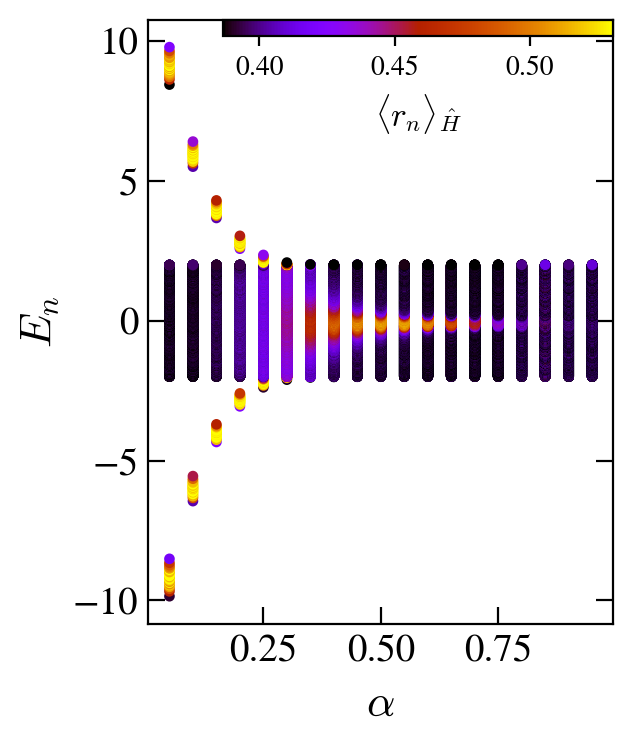

In [33]:

markers = itertools.cycle(markers_ls)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(3,4), dpi = 200)

J=1

alfa=0.6
h=0
w=2
zeta=0.2

N=100
gamma=1
ini_ave=0

L = 20000

alfa_vals = np.arange(0.05, 1.3, 0.05)
print(alfa_vals)
    
window = 6
projected = 1

s_m = matplotlib.cm.ScalarMappable(cmap='gnuplot', norm= matplotlib.colors.Normalize(vmin=0.3867, vmax=0.5307 ))
s_m.set_array([])

dim = L+N
for ii, alfa in enumerate(alfa_vals):
    name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('mean energies'))[1 : -1]
            gap_ratio = np.array(file.get('gap ratio'))
            E = E[::4]
            gap_ratio = gap_ratio[::4]
            
            colors = [s_m.to_rgba(r) for r in gap_ratio]
            
            axis.scatter(np.ones(E.size) * alfa, E, color=colors, s=8)
    else:
        print(name)

fig_help.set_plot_elements(axis, ylabel=r"$E_n$", xlabel=r"$\alpha$", font_size=14, set_legend=False)

# fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.25, 0.86, 0.65, 0.02])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$\langle r_n\rangle_{\hat{H}}$", fontsize=12)
cbar_ax.xaxis.set_ticks_position('bottom')
cbar_ax.xaxis.set_label_position('bottom')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [39]:
print( 0.8**(7.2) / 0.8**(7))
print( 6.8**0.8 / 7**0.8, 7**0.8 / 7.2**0.8)

0.956352499790037
0.9770767927174313 0.9777153528430895


### FINITE SIZE SCALING

[0.05 0.15 0.5  0.9 ]
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.1,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0.2,alfa=0.1,h=0,w=2.hdf5


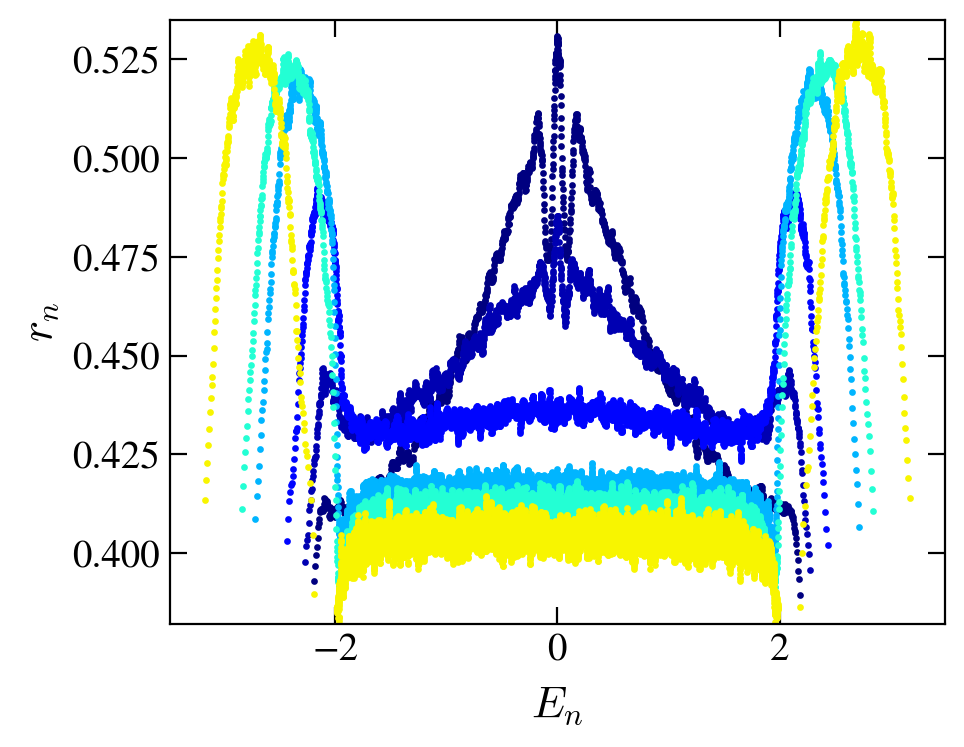

In [90]:
markers = itertools.cycle(markers_ls)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

J=1

alfa=0.1
h=0
w=2
zeta=0.2

N=500
gamma=1
ini_ave=0

L = 20000

alfa_vals = np.array( [0.05, 0.15, 0.5, 0.9] )
print(alfa_vals)

sizes = np.array( [1000, 2000, 4000, 8000, 10000, 16000, 20000, 24000] )
window = 10
_smooth = 1

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

for L in sizes:
    dim = L+N
    col = s_m.to_rgba(L)
    name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('mean energies'))[1 : -1]
            gap_ratio = np.array(file.get('gap ratio'))
            
            if _smooth:
                E = E[window//2 : -window//2]
                gap_ratio = tools.remove_fluctuations(gap_ratio, bucket_size=window)[window//2 : -window//2]
            axis.scatter(E, gap_ratio, color=col, s=2)
    else:
        print(name)

fig_help.set_plot_elements(axis, ylabel=r"$r_n$", xlabel=r"$E_n$", font_size=14, set_legend=False, ylim=(0.382, 0.535))


fig.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4
 1.45]
../results/DIAGONALIZATION/_L=16000,N=500,J=1,g=1,zeta=0.2,alfa=1.25,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=16000,N=500,J=1,g=1,zeta=0.2,alfa=1.3,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=16000,N=500,J=1,g=1,zeta=0.2,alfa=1.35,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=16000,N=500,J=1,g=1,zeta=0.2,alfa=1.4,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=16000,N=500,J=1,g=1,zeta=0.2,alfa=1.45,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.8,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.85,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.9,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.95,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,alfa=1,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1

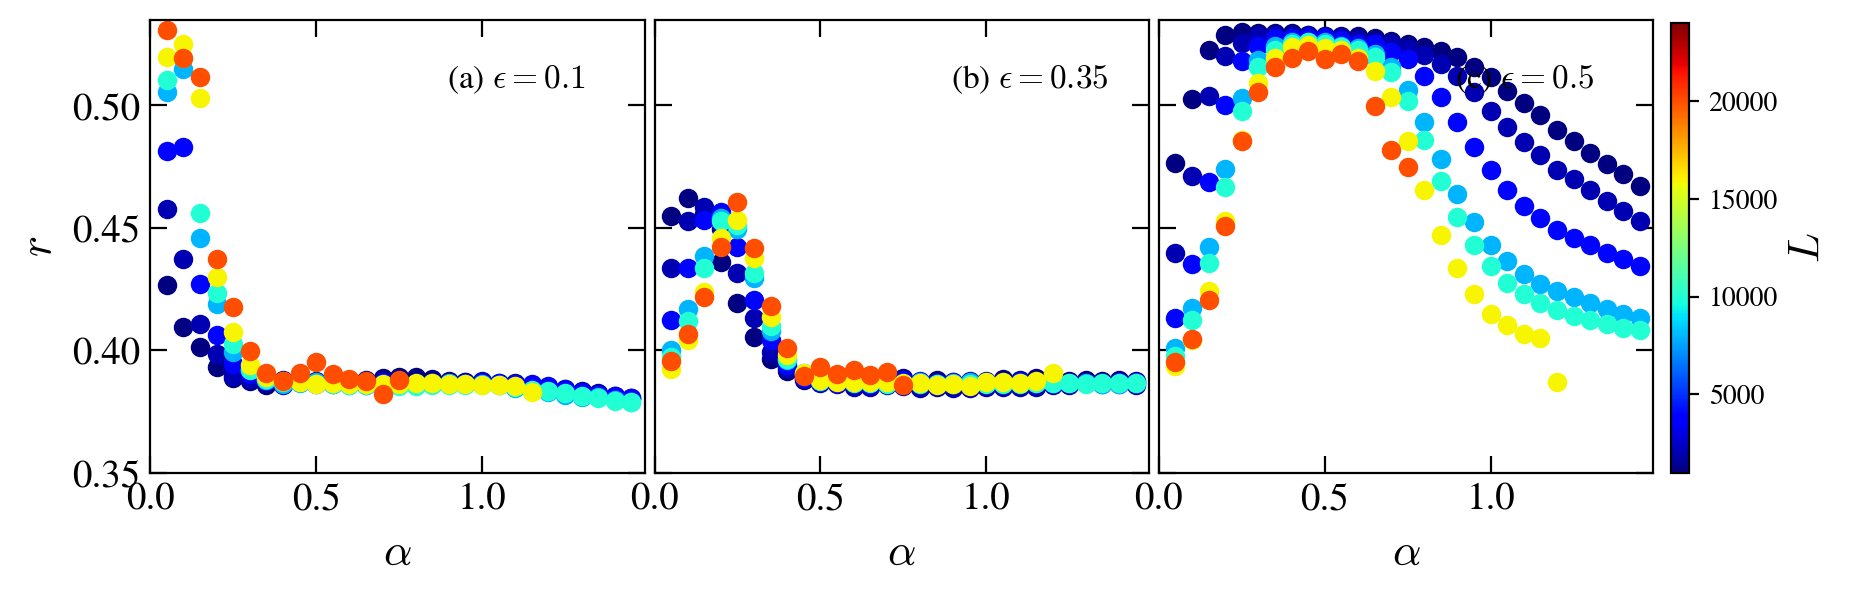

In [25]:

markers = itertools.cycle(markers_ls)

J=1

alfa=0.6
h=0
w=2
zeta=0.2

N=500
gamma=1
ini_ave=0

L = 4000

alfa_vals = np.arange(0.05, 1.5, 0.05)
print(alfa_vals)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []

sizes = np.array( [1000, 2000, 4000, 8000, 10000, 16000, 20000, 24000] )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

epsilons = [0.1, 0.35, 0.5]
fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(9,3), dpi = 200, sharey = True)
labs = ["(a)", "(b)", "(c)", "(d)"]

for L in sizes:
    col = s_m.to_rgba(L)
    
    gap_ratio = np.zeros( (3, alfa_vals.size) ); gap_ratio.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('energy_density'))
                for iie, eps in enumerate(epsilons):
                    idx = np.argmin( np.abs(E - eps) )
                    gap_ratio[iie, ii] = np.array(file.get('gap_ratio_density'))[idx]
        else:
            print(name)

    for iie, eps in enumerate(epsilons):
        axis[iie].scatter(alfa_vals, gap_ratio[iie], color=col)

for iie, eps in enumerate(epsilons):    
    fig_help.set_plot_elements(axis[iie], ylabel=r"$r$" if iie == 0 else "", xlabel=r"$\alpha$", font_size=14, set_legend=False, xlim = (0, 1.49), ylim=(0.35, 0.535))
    axis[iie].annotate(labs[iie] + r" $\epsilon=%g$"%eps, fontsize=12, xy=(0.6, 0.85), xycoords='axes fraction')

fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.97, 0.125, 0.01, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

### DENSITY OF STATES

[0.05 0.15 0.25 0.4  0.5  0.6  0.8  1.   1.2 ]
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.15,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0.2,alfa=0.15,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.25,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0.2,alfa=0.25,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.4,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0.2,alfa=0.4,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.5,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0.2,alfa=0.5,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.6,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0

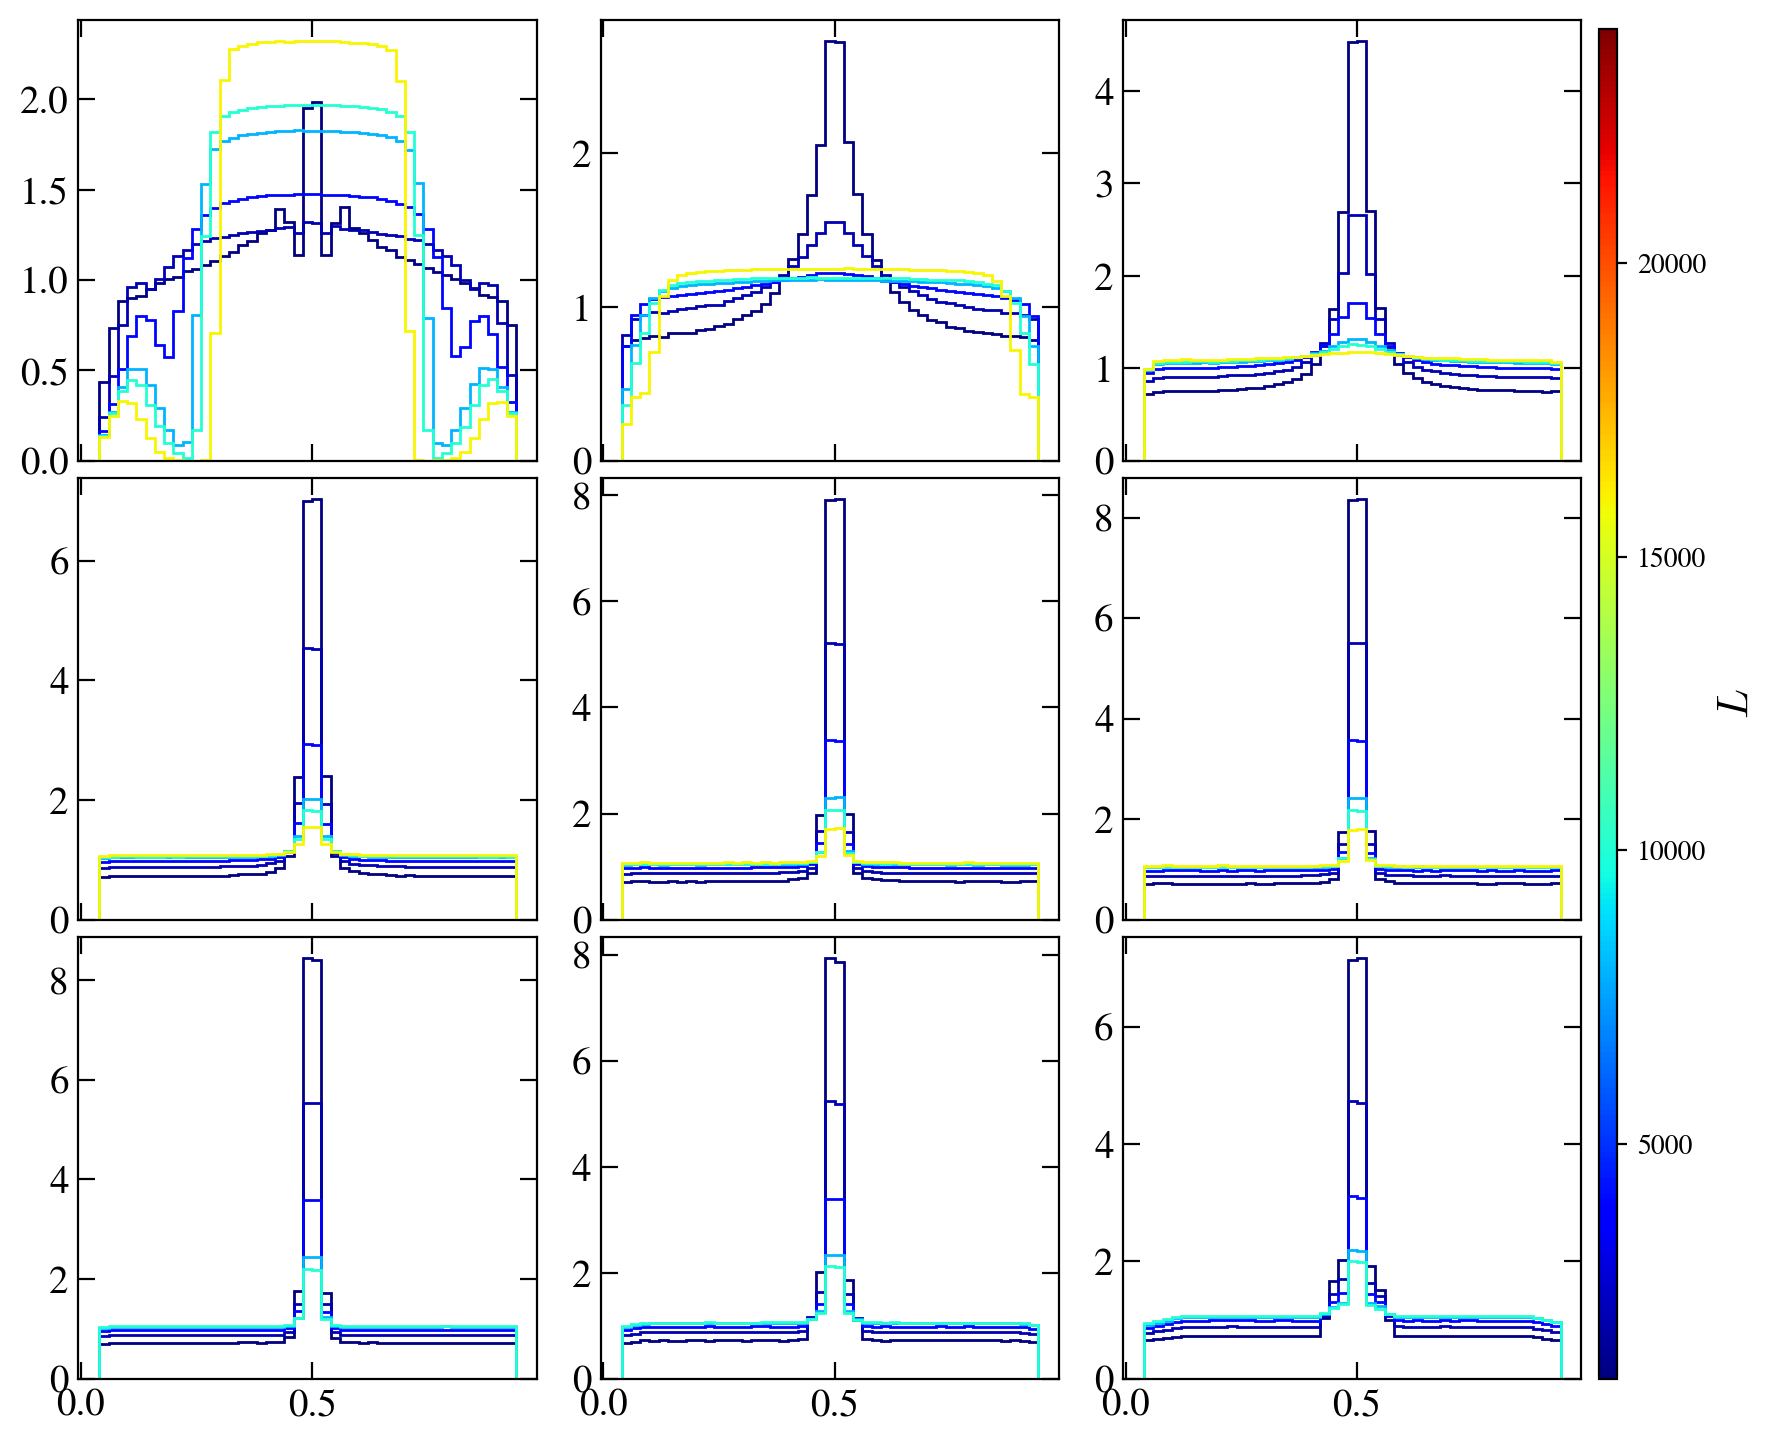

In [59]:

markers = itertools.cycle(markers_ls)

J=1

alfa=0.6
h=0
w=2
zeta=0.2

N=500
gamma=1
ini_ave=0

L = 4000

alfa_vals = np.arange(0.2, 1.2, 0.1)
alfa_vals = np.array( [0.05, 0.15, 0.25, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2] )
print(alfa_vals)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []

sizes = np.array( [1000, 2000, 4000, 8000, 10000, 16000, 20000, 24000] )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=3, ncols=3, figsize=(9,9), dpi = 200, sharex = True)
axis = axis.flatten()

for ii, alfa in enumerate(alfa_vals):
    for L in sizes:
        col = s_m.to_rgba(L)
        name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('energy_density'))
                db = E[1] - E[0]
                bins = np.array([E[0] - db/2, *(E + db/2)])
                DOS = np.array(file.get('DOS')) / (L+N)
                
                axis[ii].stairs(DOS, bins, color=col)
        else:
            print(name)

    fig_help.set_plot_elements(axis[ii], ylabel=r"$\rho/V$" if iie %3== 0 else "", xlabel=r"$\epsilon$" if iie > 5 else "", font_size=14, set_legend=False)

fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.97, 0.125, 0.01, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

fig.subplots_adjust(wspace = 0.14, hspace=0.04)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15]
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.8,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.85,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.9,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=0.95,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,alfa=1,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=1.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=1.1,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=20000,N=500,J=1,g=1,zeta=0.2,alfa=1.15,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0.2,alfa=0.1,h=0,w=2.hdf5
../results/DIAGONALIZATION/_L=24000,N=500,J=1,g=1,zeta=0.2,alfa=0.15,h=0,w=2.hd

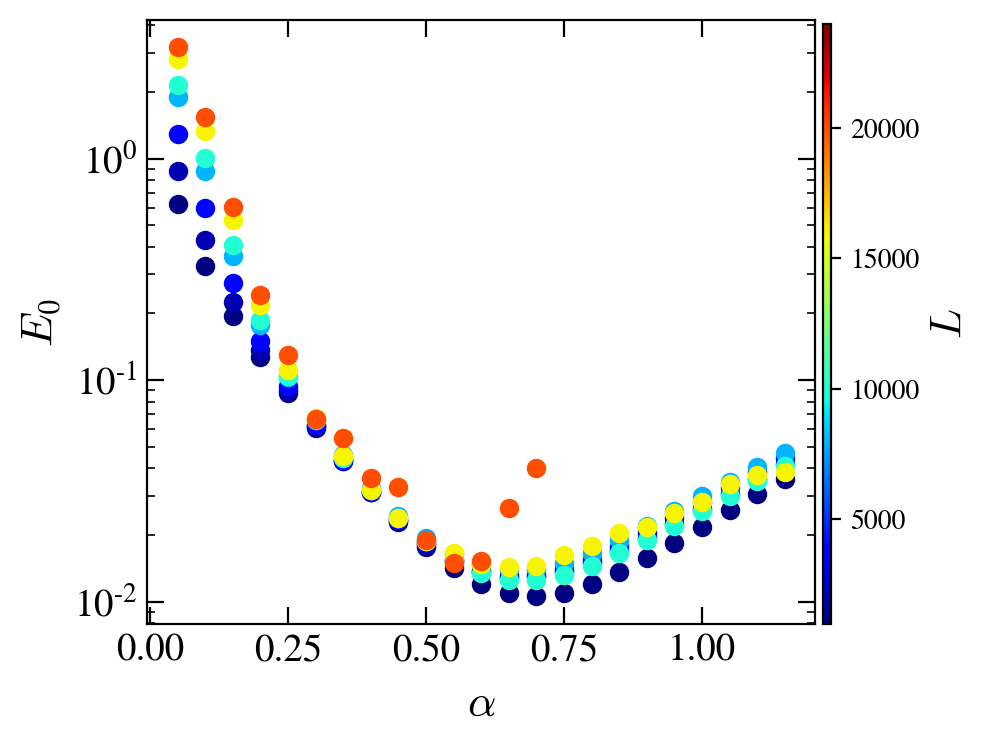

In [28]:

markers = itertools.cycle(markers_ls)

J=1

alfa=0.6
h=0
w=2
zeta=0.2

N=500
gamma=1
ini_ave=0

L = 4000

alfa_vals = np.arange(0.05, 1.2, 0.05)
print(alfa_vals)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []

sizes = np.array( [1000, 2000, 4000, 8000, 10000, 16000, 20000, 24000] )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200, sharex = True)


for L in sizes:
    col = s_m.to_rgba(L)
    E0 = np.zeros(alfa_vals.shape); E0.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                E0[ii] = -np.mean(np.array(file.get('low_energies'))[:,0] ) - 2
                
        else:
            print(name)
    axis.scatter(alfa_vals, E0, color=col)
fig_help.set_plot_elements(axis, ylabel=r"$E_0$", xlabel=r"$\alpha$", font_size=14, set_legend=False, yscale='log')

fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.97, 0.125, 0.01, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

fig.subplots_adjust(wspace = 0.14, hspace=0.04)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)